In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

root_str = str(PROJECT_ROOT)
if root_str in sys.path:
    sys.path.remove(root_str)
sys.path.insert(0, root_str)

#print("PROJECT_ROOT =", PROJECT_ROOT)
#print("cwd =", Path.cwd())

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch
from datetime import datetime
import yaml

In [4]:
control_key = "is_control"
condition_keys = "guide_merged"
condition_rep_keys = "gene_embeddings"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
data_origin = "Norman_42_0.1_True_X_pca_scaled_128"  #{dataset_name}_{random_seed}_{test_ratio}_{zero_shot}_{sample_rep_scaled}_{n_comps}
sample_rep = "X_pca_scaled"

In [5]:
preprocess_save_path = f"./data/processed/{data_origin}"
adata_control = sc.read_h5ad(f"{preprocess_save_path}_control.h5ad")
adata_train = sc.read_h5ad(f"{preprocess_save_path}_train.h5ad")
if os.path.exists(f"{preprocess_save_path}_test.h5ad"):
    adata_test = sc.read_h5ad(f"{preprocess_save_path}_test.h5ad")
else:
    adata_test = None
print(adata_control)
print(adata_train)
print(adata_test)

AnnData object with n_obs × n_vars = 8395 × 33694
    obs: 'guide_identity', 'UMI_count', 'gemgroup', 'number_of_cells', 'guide_merged', 'is_control'
    var: 'gene_symbols'
    uns: 'log1p', 'pca'
    obsm: 'X_pca', 'X_pca_scaled'
    varm: 'PCs', 'X_mean'
    layers: 'X_centered', 'counts'
AnnData object with n_obs × n_vars = 85487 × 33694
    obs: 'guide_identity', 'UMI_count', 'gemgroup', 'number_of_cells', 'guide_merged', 'is_control'
    var: 'gene_symbols'
    uns: 'log1p'
    obsm: 'X_pca', 'X_pca_scaled', 'gene_embeddings'
    layers: 'counts'
AnnData object with n_obs × n_vars = 7837 × 33694
    obs: 'guide_identity', 'UMI_count', 'gemgroup', 'number_of_cells', 'guide_merged', 'is_control'
    var: 'gene_symbols'
    uns: 'log1p'
    obsm: 'X_pca', 'X_pca_scaled', 'gene_embeddings'
    layers: 'counts'


## training

In [6]:
from src.training import pre_compute_wfr_ot, seed_everything
from src.training import FNet,train
from torch.optim.lr_scheduler import CosineAnnealingLR

In [ ]:
delta = 10
reg_m = 1
use_mini_batch_uot = False # mini_batch逻辑暂时还没有写
group_number = 3
ot_origin = f"delta{delta}_regm{reg_m}"
save_path_train = f"./experiments/ot_plan/ot_precompute_{data_origin}_{ot_origin}_train.pkl"
save_path_test = f"./experiments/ot_plan/ot_precompute_{data_origin}_{ot_origin}_test.pkl"

load_saved = True
if os.path.exists(save_path_train) and load_saved:
    print(f"read{save_path_train}")
    ot_results_train = pd.read_pickle(save_path_train)
else:
    ot_results_train = pre_compute_wfr_ot(adata_control, 
                           adata_train, 
                           save_path_train, 
                           sample_rep=sample_rep, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw = False)

if os.path.exists(save_path_test) and load_saved:
    print(f"read{save_path_test}")
    ot_results_test = pd.read_pickle(save_path_test)
else:
    ot_results_test = pre_compute_wfr_ot(adata_control, 
                           adata_test, 
                           save_path_test, 
                           sample_rep=sample_rep, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw=False)


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/training/utils.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_indices = adata_treated.obs.groupby(condition_keys).indices
100%|██████████| 10/10 [00:11<00:00,  1.19s/it]


Batch saved: 10/255


100%|██████████| 10/10 [00:02<00:00,  3.52it/s]


Batch saved: 20/255


100%|██████████| 10/10 [00:03<00:00,  2.57it/s]


...

100%|██████████| 10/10 [00:02<00:00,  4.45it/s]


Batch saved: 170/255


100%|██████████| 10/10 [00:02<00:00,  3.86it/s]


Batch saved: 180/255


 30%|███       | 3/10 [00:00<00:01,  3.84it/s]

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

n_iterations = 30000

load_experiment = False # 如果是False可以无视下面三个参数
experiment_load_path = "experiments/exp_20260128_213143_ArcVirtualCell_42_0.1_False_X_pca_scaled_delta10_regm1"
config_load_path = os.path.join(experiment_load_path, "config.yaml")
model_load_path = os.path.join(experiment_load_path, "checkpoints", "test_epoch_10.pt") 

if not load_experiment:
    experiment_save_path = os.path.join("experiments", f"exp_{timestamp}_{data_origin}_{ot_origin}")
    checkpoint_save_path = os.path.join(experiment_save_path, "checkpoints")
    os.makedirs(checkpoint_save_path, exist_ok=True)
    
    config = {
        "in_out_dim": adata_control.obsm[sample_rep].shape[1],
        "condition_dim": adata_train.obsm[condition_rep_keys].shape[1],
        
        "hidden_dim_v": 4096,   
        "hidden_dim_g": 2048,
        "n_hiddens_v": 4,
        "n_hiddens_g": 2,
    
        "con_embedding_dim": 512,
        "hidden_dim_con": 1024,
        
        "time_dim": 1024,
        "time_embedding_dim": 256,
        "hidden_dim_time": 512,
        
        "bottle_dim": 1024,
        "activation": 'SiLU',
        
        "batch_size_per_condition": 256,  
        "batch_size_condition":10,
        "learning_rate": 5e-5,  
        "weight_decay":1e-4,
        "eta_min":5e-6,
        "seed": 42,
        "eval_interval":10,
    }
    config_save_path = f"{experiment_save_path}/config.yaml"
    with open(config_save_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
        print(f"config saved to {config_save_path}")
else:
    with open(config_load_path, 'r') as f:
        config = yaml.safe_load(f)
        print(f"load saved_config from {config_load_path}")

    experiment_save_path = experiment_load_path  #直接继续某一个实验
    checkpoint_save_path = os.path.join(experiment_save_path, "checkpoints")


model = FNet(config["in_out_dim"], config["hidden_dim_v"], config["n_hiddens_v"], config["hidden_dim_g"], config["n_hiddens_g"], 
             config["condition_dim"], config["con_embedding_dim"], config["hidden_dim_con"], 
             config["time_dim"] ,config["time_embedding_dim"],config["hidden_dim_time"], 
             config["bottle_dim"], config["activation"])
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=n_iterations, eta_min=config["eta_min"])
seed_everything(config["seed"])

if load_experiment:    
    if os.path.exists(model_load_path):
        checkpoint = torch.load(model_load_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        print(f"load model from {model_load_path}")
    else:
        print("wrong model_load_path")

print("setup complete")

In [ ]:
model_save_path = os.path.join(checkpoint_save_path, "test")
train.train_model(adata_control, adata_train, adata_test,
                ot_results_train, ot_results_test, 
                model.to(device),
                optimizer,
                scheduler = scheduler,
                n_iterations= n_iterations,
                batch_size_per_condition = config["batch_size_per_condition"],
                batch_size_condition = config["batch_size_condition"],
                sample_rep = sample_rep,
                condition_keys=condition_keys,
                condition_rep_keys = condition_rep_keys,
                device = device,
                save_path=model_save_path,
                eval_interval = config["eval_interval"],
                save_interval = 5000, #每隔多少轮保存一次
                save_only_last = True) # 是否只保留最后的pt文件


训练步数: 14900
最后一步 Loss: 0.031212
最后一步 vLoss: 0.030972
最后一步 gLoss: 0.000239
最后一步 test_Loss: 0.300349
最后一步 test_vLoss: 0.017008
最后一步 test_gLoss: 0.283342


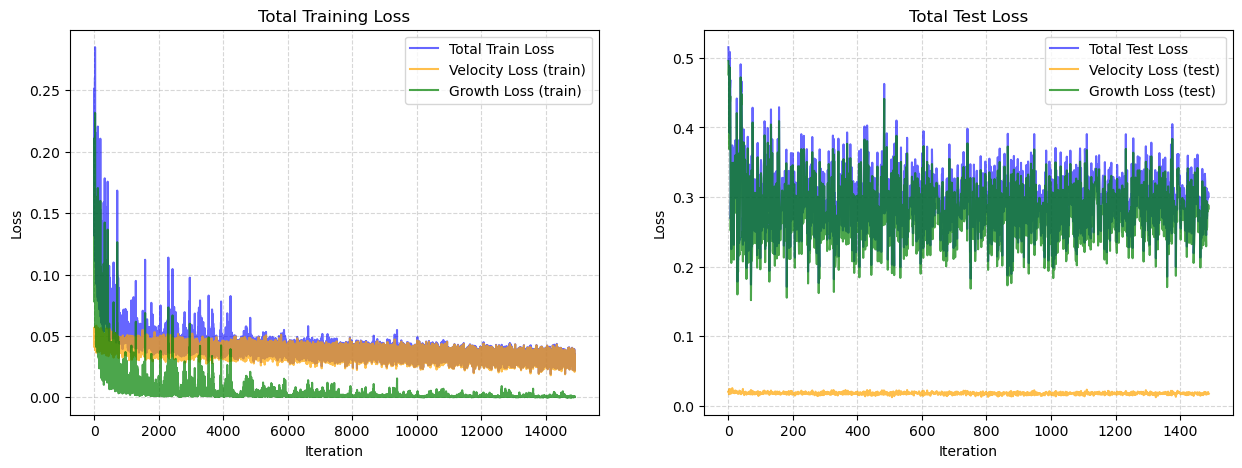

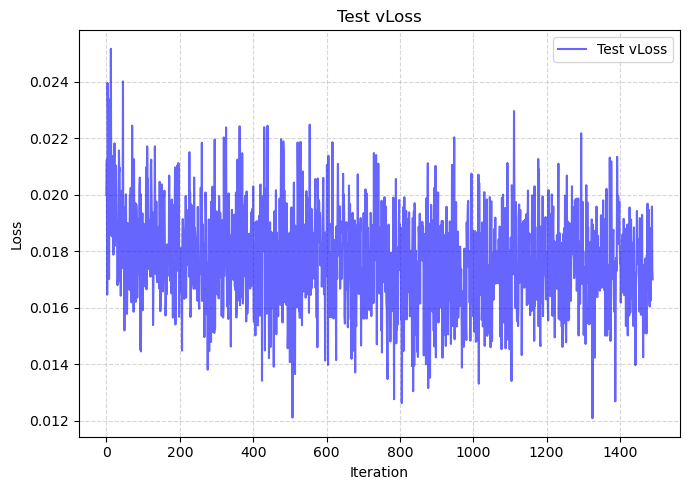

In [14]:
from src.evaluate import draw_loss
load_path = f"{model_save_path}_epoch_15000.pt"
draw_loss(load_path,eval_interval = 10,cut = 100,save_path = experiment_save_path) # cut代表去掉前多少个epoch 避免前期loss过大影响观察